In [6]:
import * as tslab from "tslab";
import { readFileSync } from "fs";

const css = readFileSync("../style.css", "utf-8");
tslab.display.html(`<style>${css}</style>`);

# The Fibonacci Numbers

The [Fibonacci numbers](https://en.wikipedia.org/wiki/Fibonacci_number) $F_n$ are defined by induction for all $n\in\mathbb{N}$:
  - $F_0 := 0$,
  - $F_1 := 1$, 
  - $F_{n+2} = F_{n+1} + F_n$ for all $n \in \mathbb{N}$.

Given a natural number `n`, the function `fibonacci(n)` computes the number $F_n$.

In [1]:
function fibonacci(n: number): number {
  if (n <= 1) {
    return n;
  }
  return fibonacci(n - 1) + fibonacci(n - 2);
}

In [2]:
const values: [number, number][] = [];
for (let n = 0; n < 19; n++) {
  values.push([n, fibonacci(n)]);
}

console.log(values);

[
  [ 0, 0 ],     [ 1, 1 ],
  [ 2, 1 ],     [ 3, 2 ],
  [ 4, 3 ],     [ 5, 5 ],
  [ 6, 8 ],     [ 7, 13 ],
  [ 8, 21 ],    [ 9, 34 ],
  [ 10, 55 ],   [ 11, 89 ],
  [ 12, 144 ],  [ 13, 233 ],
  [ 14, 377 ],  [ 15, 610 ],
  [ 16, 987 ],  [ 17, 1597 ],
  [ 18, 2584 ]
]


It seems that the *Fibonacci numbers* grow pretty fast. Let us plot these numbers to get a better understanding of their growth.

In [3]:
import { ChartJSNodeCanvas } from "chartjs-node-canvas";
import { Chart, registerables, ChartConfiguration } from "chart.js";
import { display } from "tslab";


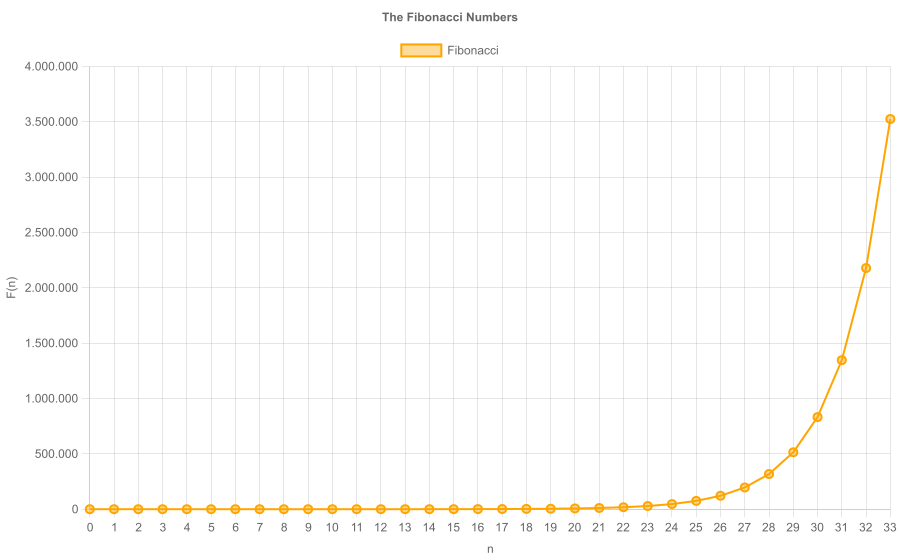

In [6]:
Chart.register(...registerables);

const m = 34;
const X = Array.from({ length: m }, (_, n) => n);
const Y = X.map(fibonacci);

const width = 900;
const height = 560;
const chartJSNodeCanvas = new ChartJSNodeCanvas({
  width,
  height,
  backgroundColour: "white",
});

const config: ChartConfiguration<"line", number[], string> = {
  type: "line",
  data: {
    labels: X.map(String),
    datasets: [
      {
        label: "Fibonacci",
        data: Y,
        pointRadius: 4,
        borderWidth: 2,
        borderColor: "rgb(255,165,0)",
        backgroundColor: "rgba(255,165,0,0.4)",
      },
    ],
  },
  options: {
    plugins: {
      title: { display: true, text: "The Fibonacci Numbers" },
    },
    scales: {
      x: { title: { display: true, text: "n" } },
      y: { title: { display: true, text: "F(n)" } },
    },
  },
};

const buffer = await chartJSNodeCanvas.renderToBuffer(config, "image/png");
const base64 = buffer.toString("base64");
const html = `<img src="data:image/png;base64,${base64}" alt="Fibonacci Chart" />`;
display.html(html);

It looks like the *Fibonacci numbers* grow exponentially.  Let us confirm this hypothesis by plotting the logarithm of these numbers.

In [ ]:
import math


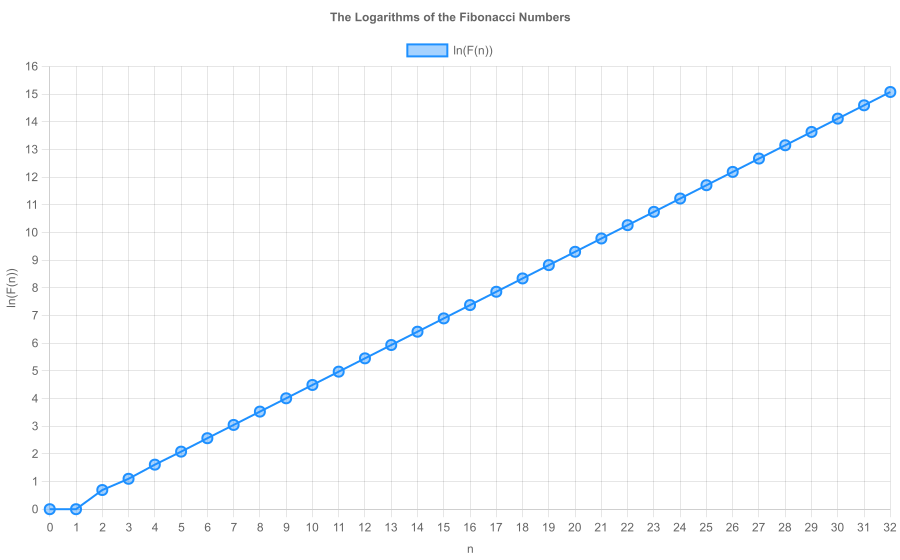

In [ ]:
Chart.register(...registerables);

const X1 = X.slice(1);
const Y1 = Y.slice(1);

const logY = Y1.map(y => Math.log(y));

const width = 900;
const height = 560;
const chartJSNodeCanvas = new ChartJSNodeCanvas({
  width,
  height,
  backgroundColour: "white",
});

const config: ChartConfiguration<"line", number[], string> = {
  type: "line",
  data: {
    labels: X1.map(String),
    datasets: [
      {
        label: "ln(F(n))",
        data: logY,
        borderColor: "rgb(30,144,255)",
        backgroundColor: "rgba(30,144,255,0.4)",
        pointRadius: 5,
        borderWidth: 2,
        tension: 0, 
      },
    ],
  },
  options: {
    plugins: {
      title: {
        display: true,
        text: "The Logarithms of the Fibonacci Numbers",
      },
    },
    scales: {
      x: {
        title: { display: true, text: "n" },
        ticks: { callback: (val) => val.toString() },
      },
      y: {
        title: { display: true, text: "ln(F(n))" },
        ticks: { stepSize: 1 },
      },
    },
  },
};

const buffer = await chartJSNodeCanvas.renderToBuffer(config, "image/png");
const base64 = buffer.toString("base64");
const html = `<img src="data:image/png;base64,${base64}" alt="Logarithmic Fibonacci Chart" />`;
display.html(html);

This plot looks linear and confirms our hypothesis that these numbers grow exponentially.

Computing the *Fibonacci numbers* took quite long.  Lets measure these times and plot them.

In [ ]:
x = 1
y = 2
f'{x} + {y} = {x + y}'

In [ ]:
import time

In [ ]:
m = 36
Y = []
X = list(range(m))
for n in range(m):
    start = time.time()
    print(f'fib({n}) = {fibonacci(n)}')
    stop  = time.time()
    print(stop - start)
    Y.append(stop - start)
    
sns.set_style('darkgrid')
plt.figure(figsize=(15, 10))
plt.plot(X, Y, 'bo') 
plt.xticks(X)
plt.xlabel('n')
plt.ylabel('time in seconds')
plt.title('Time to Compute the Fibonacci Numbers')
plt.show()

The times seem to grow exponentially.  

In [ ]:
m = 36
Y = []
X = list(range(20, m))
for n in X:
    start = time.time()
    fibonacci(n)
    stop  = time.time()
    Y.append(math.log(stop - start))
    
sns.set_style('darkgrid')
plt.figure(figsize=(15, 10))
plt.plot(X, Y, 'bo') 
plt.xticks(X)
plt.xlabel('n')
plt.ylabel('time in seconds')
plt.title('Logarithm of the Time to Compute the Fibonacci Numbers')
plt.show()

The logarithmic plot confirms this.  In order to investigate the reason for this exponential growth, we compute the *computation tree*.  This tree shows the recursive invocations of the function.

In [ ]:
import graphviz as gv

In [ ]:
class ComputationTree:
    def __init__(self, arg, value, left=None, right=None):
        self.mArg   = arg
        self.mValue = value
        self.mLeft  = left
        self.mRight = right

In [ ]:
def isLeaf(self):
    return self.mLeft == None and self.mRight == None

ComputationTree.isLeaf = isLeaf
del isLeaf

In [ ]:
def toDot(self):
    ComputationTree.sCounter = 0 # static variable of the class ComputationTree
    dot = gv.Digraph(node_attr={'shape': 'record', 'style': 'rounded'})
    NodeDict = {}
    self._assignIDs(NodeDict)
    for n, t in NodeDict.items():
        dot.node(str(n), label='{' + str(t.mArg) + '|' + str(t.mValue) + '}')
        if t.mLeft != None and t.mRight != None:
            dot.edge(str(n), str(t.mLeft .mID))
            dot.edge(str(n), str(t.mRight.mID))
    return dot

ComputationTree.toDot = toDot
del toDot

In [ ]:
def _assignIDs(self, NodeDict):
    ComputationTree.sCounter += 1
    self.mID = ComputationTree.sCounter
    NodeDict[self.mID] = self
    if self.isLeaf():
        return
    self.mLeft ._assignIDs(NodeDict)
    self.mRight._assignIDs(NodeDict)
    
ComputationTree._assignIDs = _assignIDs
del _assignIDs

In [ ]:
def fibonacci_tree(n):
    if n <= 1:
        return ComputationTree(n, n)
    C1 = fibonacci_tree(n-1)
    C2 = fibonacci_tree(n-2)
    return ComputationTree(n, C1.mValue + C2.mValue, C1, C2)

In [ ]:
t = fibonacci_tree(6)
t.toDot()

The *computation tree* for the computation of `fibonacci(6)` shows the reason for the inefficiency:
* `fibonacci(5)` is computed once,
* `fibonacci(4)` is computed 2 times,
* `fibonacci(3)` is computed 3 times,
* `fibonacci(2)` is computed 5 times,
* `fibonacci(1)` is computed 8 times, and
* `fibonacci(0)` is computed 5 times.

If we want to compute the Fibonacci numbers efficiently, we must not compute the value `fibonacci(n)` for a given `n` more than once.  The easiest way to achieve this is by storing the Fibnacci numbers in a list `L`.  In the implementation below, `L[n]` stores the $n$-th Fibonacci number.

In [ ]:
def fibonacci_mem(n):
    if n <= 1:
        return n
    L    = [0 for k in range(n+1)]
    L[0] = 0
    L[1] = 1
    for k in range(2, n+1):
        L[k] = L[k-1] + L[k-2]
    return L[n]

Now it is even possible to compute the $100,000^\mbox{th}$ *Fibonnaci number*.

In [ ]:
%%time
x = fibonacci_mem(100_000)

In [ ]:
x